# Convolutional Neural Networks for Eye Disease Detection

## Authors

Laura Cahill, Olivia Jones-Martin, Roberto Mercado, Zuriel Pagan

## Dataset

We use the [Retinal Fundus Multi-disease Image Dataset (RFMiD)](https://ieee-dataport.org/open-access/retinal-fundus-multi-disease-image-dataset-rfmid?check_logged_in=1) for this project, which is available on the IEEE DataPort website. It contains 3200 fundus color images captured by three different fundus cameras. The dataset is divided into a training set of 1920 images, validation set of 640 images, and testing set of 640 images. Ground truth labels are provided through CSV files, which account for 1 healthy class and 45 disease classes. There is an alternative dataset that contains 29 labels in total, which we used for our models due to the severe class imbalance.

## Prerequisites

The following Python 3.12 modules are required to execute the cells of this notebook.

In [1]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from utilities import *
import pandas as pd
import seaborn as sns

The following constants assume that the dataset was downloaded from the IEEE DataPort website and placed into the same directory as this notebook.

In [2]:
DATA_PATH = 'A. RFMiD_All_Classes_Dataset'
IMAGE_PATH = f'{DATA_PATH}/1. Original Images'
GROUND_TRUTH_PATH = f'{DATA_PATH}/2. Groundtruths'
TRAINING_SET_PATH = f'{IMAGE_PATH}/a. Training Set'
VALIDATION_SET_PATH = f'{IMAGE_PATH}/b. Validation Set'
TESTING_SET_PATH = f'{IMAGE_PATH}/c. Testing Set'

GPU access is a must for complex neural networks. Running the Inception v3 model on the CPU is ill-advised.

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
display(device)

device(type='cuda')

## Dataset Setup

First, we need to set up the dataset for model evaluation. The dataset is presplit into training, validation, and testing sets already. However, we need to make sure that the healthy class can be properly classified. We can modify the metadata to address this.

In [4]:
training_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/a. RFMiD_Training_Labels.csv')
validation_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/b. RFMiD_Validation_Labels.csv')
testing_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/c. RFMiD_Testing_Labels.csv')

for metadata in (training_metadata, validation_metadata, testing_metadata):
    metadata.rename(columns={'Disease_Risk' : 'Healthy'}, inplace=True)
    metadata['Healthy'] = metadata['Healthy'].apply(lambda value: int(not value))

Now, let's configure the dataset for use by Inception v3. The FundusImageDataset class will handle the underlying logic for loading images and labels. We only need to supply the transform so that our images are properly sized for the model.

In [5]:
transform = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

training_dataset = FundusImageDataset(training_metadata, TRAINING_SET_PATH, transform)
validation_dataset = FundusImageDataset(validation_metadata, VALIDATION_SET_PATH, transform)
testing_dataset = FundusImageDataset(testing_metadata, TESTING_SET_PATH, transform)

batch_size = 16
num_workers = 16

training_sampler = torch.utils.data.RandomSampler(training_dataset)
validation_sampler = torch.utils.data.RandomSampler(validation_dataset)
testing_sampler = torch.utils.data.SequentialSampler(testing_dataset)

training_loader = DataLoader(training_dataset, batch_size=batch_size, sampler=training_sampler, num_workers=num_workers)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, sampler=validation_sampler, num_workers=num_workers)
testing_loader = DataLoader(testing_dataset, batch_size=batch_size, sampler=testing_sampler, num_workers=num_workers)

## Model Setup

Here, we set up Inception v3 for use on our dataset.

In [6]:
model = models.inception_v3(init_weights=True)
model.fc = nn.Linear(model.fc.in_features, 46)
model.aux_logits = False
model.AuxLogits = None
model = model.to(device)
display(model)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

Then, we set up the class weights, loss function, and optimizer.

In [7]:
from torchmetrics.classification import F1Score

def calculate_thresholds(probs, labels, label_count):
    best_thresholds = []

    f1 = F1Score(task='binary')

    for label in range(label_count):
        best_threshold = 0.5
        best_F1 = 0

        label_true = torch.from_numpy(labels[:, label])
        label_probs = torch.from_numpy(probs[:, label])
        for threshold in np.arange(0.05, 0.95, 0.05):
            label_prediction = (label_probs > threshold).float()
            score = f1(label_prediction, label_true)
            if score > best_F1:
                best_F1 = score
                best_threshold = threshold
        best_thresholds.append(best_threshold)

    return best_thresholds

def get_predictions(probs, thresholds):
    '''
    probs is a numpy array and thresholds is a standard python array full of scalars,
    there are as many colums as the size in thresholds
    '''
    probs = torch.from_numpy(probs)
    thresholds = torch.tensor(thresholds).unsqueeze(0)
    return (probs > thresholds).float()

In [8]:
# Get counts for each of the

import math

disease_labels = training_metadata.columns[1:]

# counts includes every class except for ID
counts = training_metadata.iloc[:, 1:].sum()
print("Disease Counts:")
print(counts)

# total amount of images and labels in the training set
image_count = training_metadata.shape[0]
label_count = counts.shape[0]
print(f"Image count: {image_count}")
print(f"Label count: {label_count}")

'''
If there is an instance where a disease appears 0 times, give a warning and
set the count value to one to prevent a divide by zero error when calculating
the weights
'''
for i in range(label_count):
    if counts.iloc[i] == 0:
        counts.iloc[i] = 1
        print(f"WARNING! Zero instances of {disease_labels[i]} in dataset")

'''
Calculate pos_weights for binary cross entropy with logits loss
pos weight for a class should be (negative counts of class)/(positive counts of class)
Documentation in reference 2
'''
pos_weights = [math.log1p((image_count - count) / count) for count in counts]
print("pos_weigths for BCEWithLogitsLoss")
print(pos_weights)

Disease Counts:
Healthy    401
DR         376
ARMD       100
MH         317
DN         138
MYA        101
BRVO        73
TSLN       186
ERM         14
LS          47
MS          15
CSR         37
ODC        282
CRVO        28
TV           6
AH          16
ODP         65
ODE         58
ST           5
AION        17
PT          11
RT          14
RS          43
CRS         32
EDN         15
RPEC        22
MHL         11
RP           6
CWS          3
CB           1
ODPM         0
PRH          2
MNF          3
HR           0
CRAO         2
TD           3
CME          4
PTCR         5
CF           3
VH           1
MCA          1
VS           1
BRAO         2
PLQ          1
HPED         1
CL           1
dtype: int64
Image count: 1920
Label count: 46
WARNING! Zero instances of ODPM in dataset
WARNING! Zero instances of HR in dataset
pos_weigths for BCEWithLogitsLoss
[1.566119037715258, 1.6304913216319328, 2.9549102790337356, 1.8011786911445467, 2.6328267798646223, 2.9449599481805677, 3.2696210

In [9]:
from torchmetrics.classification import MultilabelF1Score

# Create loss function with given weights calculated
pos_weights = torch.FloatTensor(pos_weights).to(device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weights).cuda()

# array used to average out predictions
total_probs = np.zeros((testing_metadata.shape[0], label_count))

# targets for using F1 test
targets = torch.from_numpy(testing_metadata.iloc[:, 1:].to_numpy().astype(np.float32))

In [10]:
#combined_metadata = pd.concat([training_metadata, validation_metadata, testing_metadata], ignore_index=True)
#frequencies = combined_metadata.drop('ID', axis=1).sum().to_numpy()
#weights = torch.FloatTensor((len(combined_metadata) - frequencies) / frequencies)
#weights = weights.to(device)
#criterion = nn.BCEWithLogitsLoss(weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=1e-5)
#display(weights)

## Model Evaluation

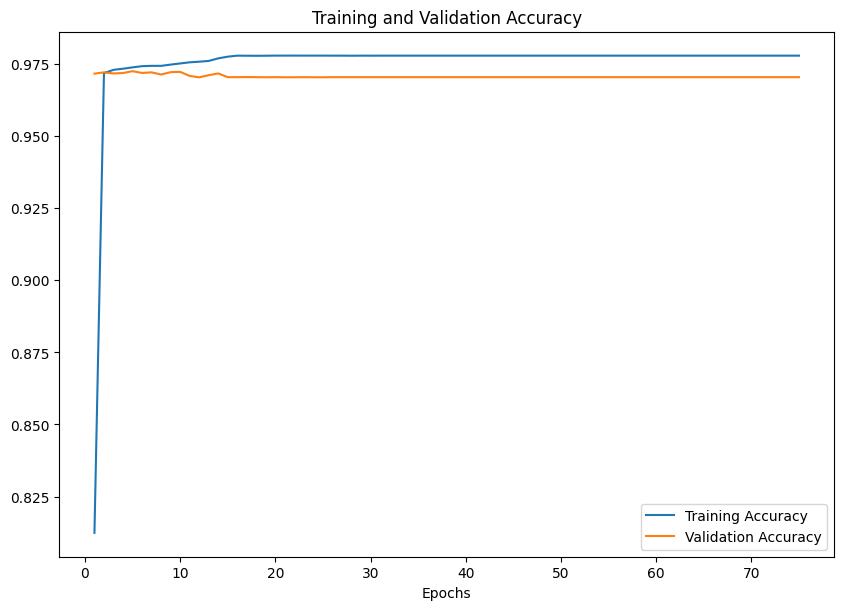

<Figure size 640x480 with 0 Axes>

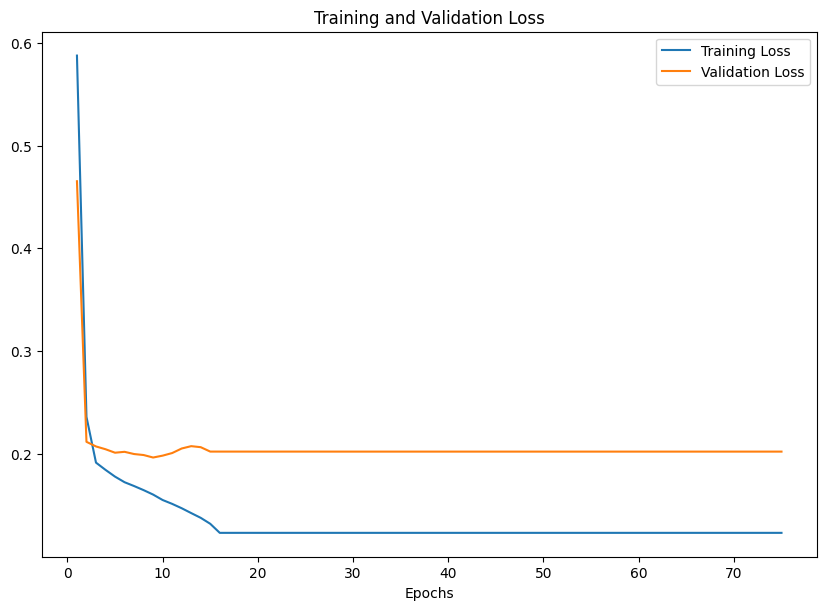

<Figure size 640x480 with 0 Axes>

In [11]:
evaluator = ModelEvaluator(
    training_loader,
    validation_loader,
    testing_loader,
    criterion,
    optimizer,
    device,
    lr_scheduler=lr_scheduler
)

results = evaluator.train(model, 75)
results.show_accuracies()
results.show_losses()

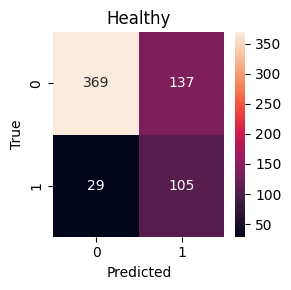

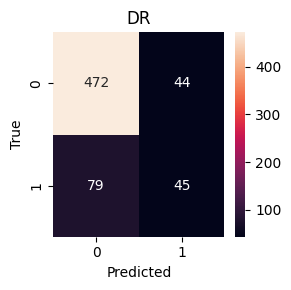

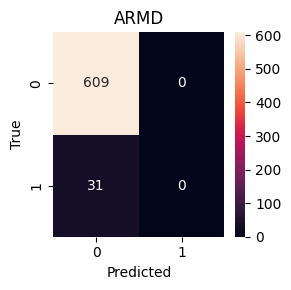

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


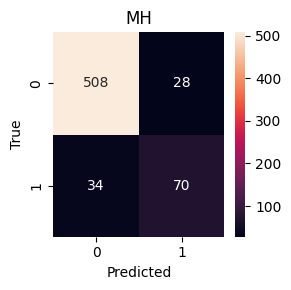

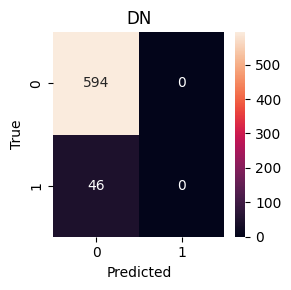

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


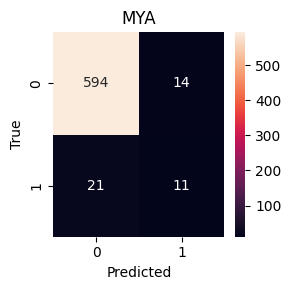

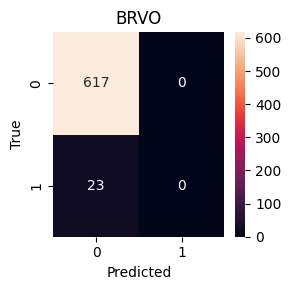

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


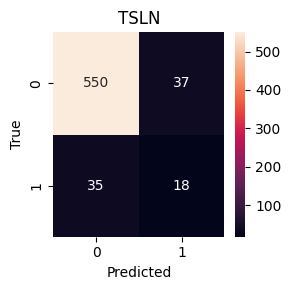

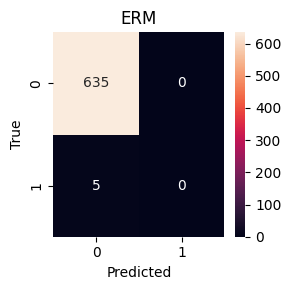

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


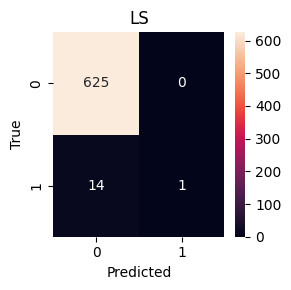

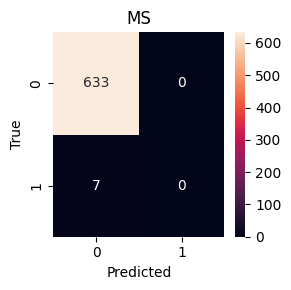

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


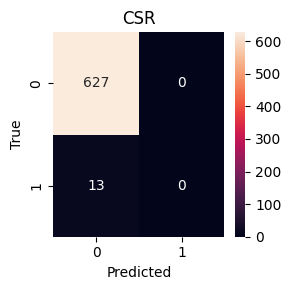

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


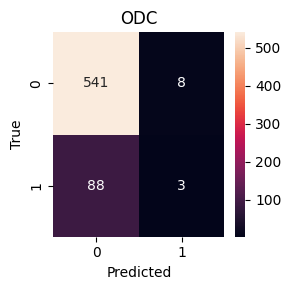

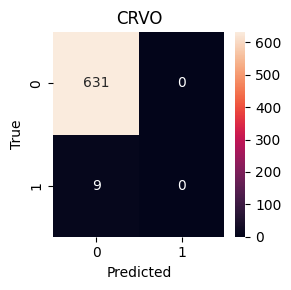

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


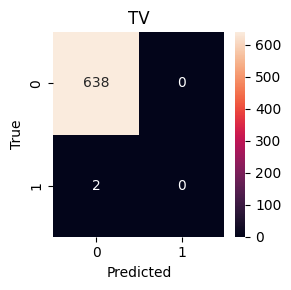

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


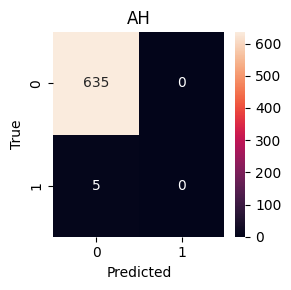

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


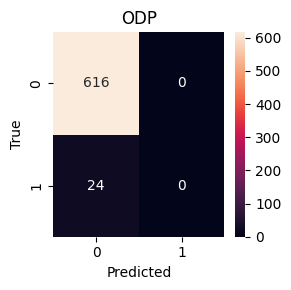

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


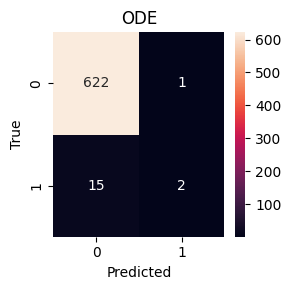

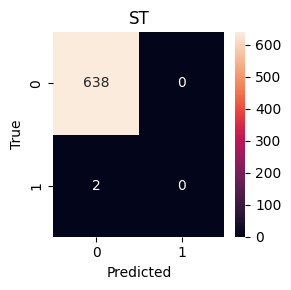

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


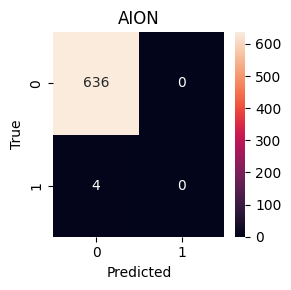

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


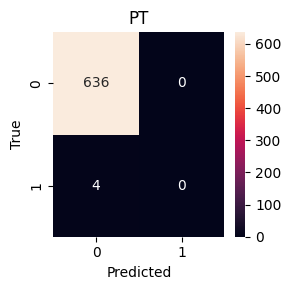

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


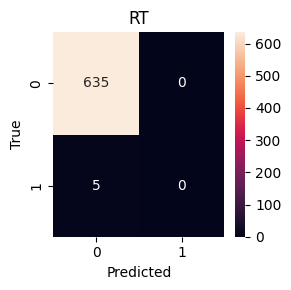

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


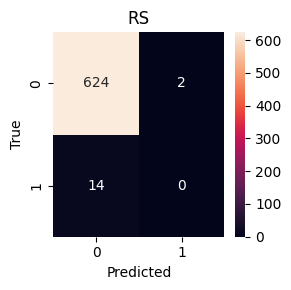

/tmp/ipykernel_1594007/1614561381.py:21: RuntimeWarning: invalid value encountered in scalar divide
  f1_score = 2 * precision * recall / (precision + recall)


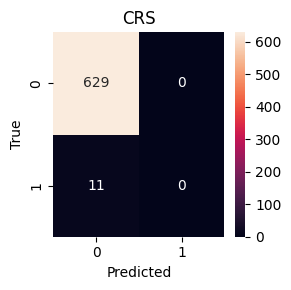

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


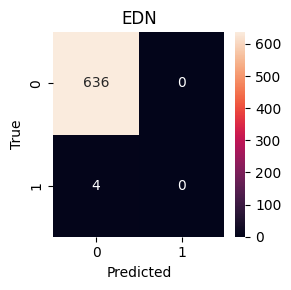

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


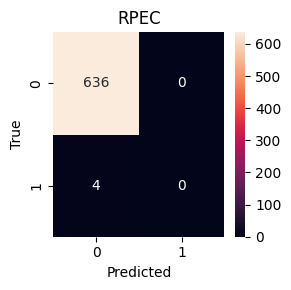

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


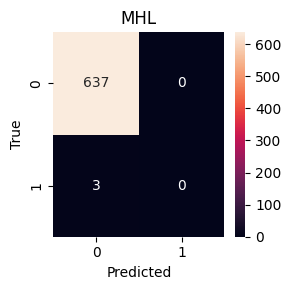

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


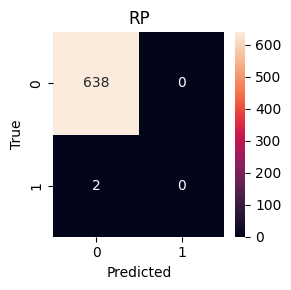

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


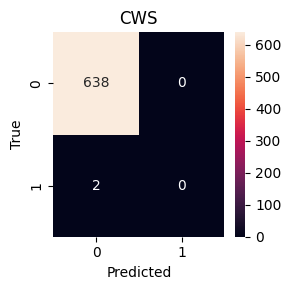

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


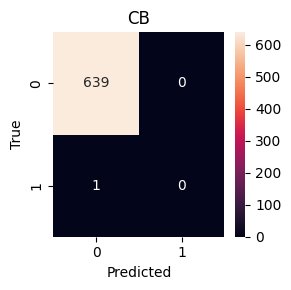

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


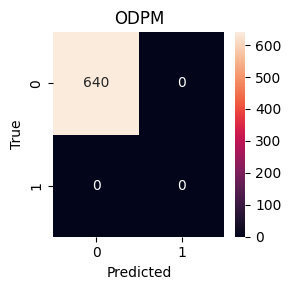

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_1594007/1614561381.py:20: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


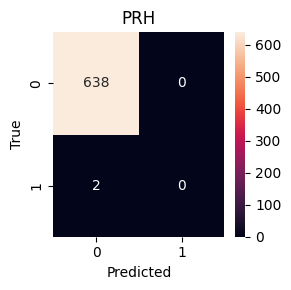

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


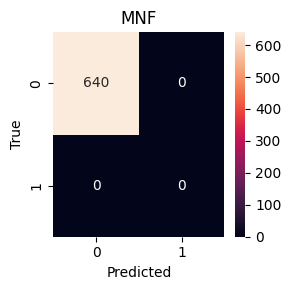

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_1594007/1614561381.py:20: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


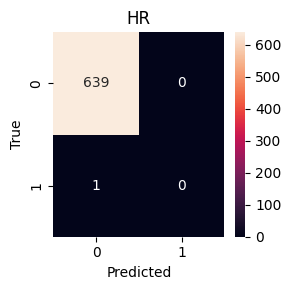

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


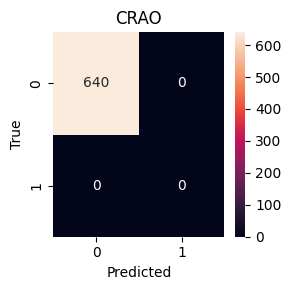

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_1594007/1614561381.py:20: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


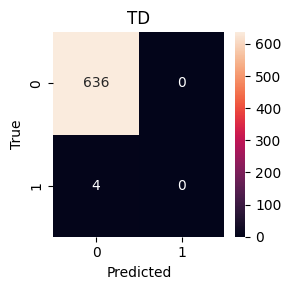

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


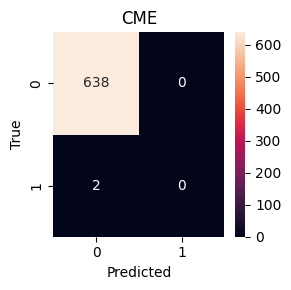

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


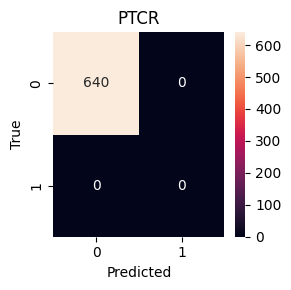

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_1594007/1614561381.py:20: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


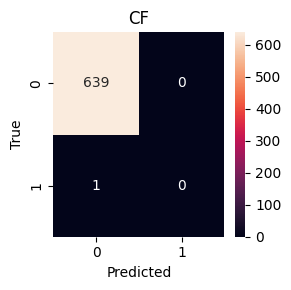

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


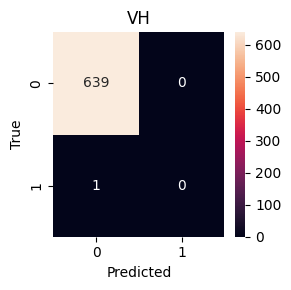

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


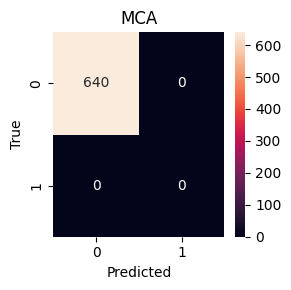

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_1594007/1614561381.py:20: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


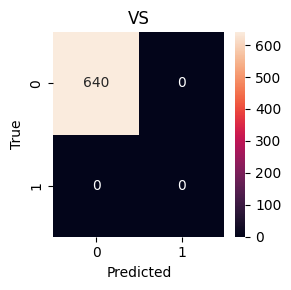

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_1594007/1614561381.py:20: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


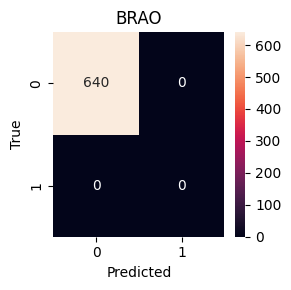

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_1594007/1614561381.py:20: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


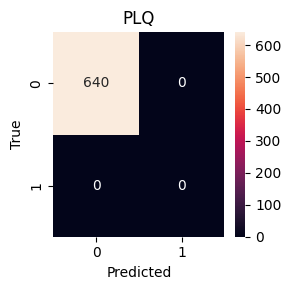

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_1594007/1614561381.py:20: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


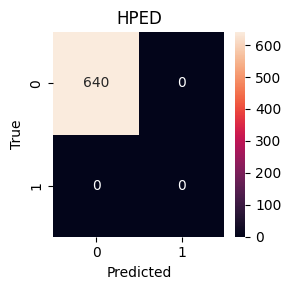

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_1594007/1614561381.py:20: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


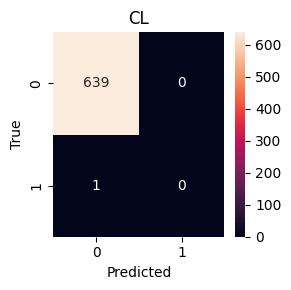

/tmp/ipykernel_1594007/1614561381.py:19: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


,Accuracy,Precision,Recall,F1 Score
Healthy,0.740625,0.433884,0.783582,0.558511
DR,0.807813,0.505618,0.362903,0.422535
ARMD,0.951562,NaN,0.000000,NaN
MH,0.903125,0.714286,0.673077,0.693069
DN,0.928125,NaN,0.000000,NaN
MYA,0.945312,0.440000,0.343750,0.385965
BRVO,0.964063,NaN,0.000000,NaN
TSLN,0.887500,0.327273,0.339623,0.333333
ERM,0.992188,NaN,0.000000,NaN
LS,0.978125,1.000000,0.066667,0.125000


In [12]:
matrices = evaluator.test(model)
metrics = pd.DataFrame(
    data={'Accuracy' : [0.0] * len(testing_dataset.classes),
          'Precision' : [0.0] * len(testing_dataset.classes),
          'Recall' : [0.0] * len(testing_dataset.classes),
          'F1 Score' : [0.0] * len(testing_dataset.classes)},
    index=testing_dataset.classes)

for label, matrix in zip(testing_dataset.classes, matrices):
    plt.figure(figsize=(3, 3))
    sns.heatmap(matrix, annot=True, fmt='d')
    plt.title(label)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
    tn, fp, fn, tp = matrix.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2 * precision * recall / (precision + recall)
    metrics.at[label, 'Accuracy'] = accuracy
    metrics.at[label, 'Precision'] = precision
    metrics.at[label, 'Recall'] = recall
    metrics.at[label, 'F1 Score'] = f1_score

display(metrics)

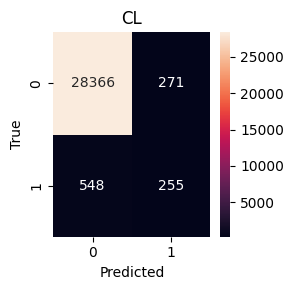

 Accuracy: 0.9721807065217392
Precision: 0.4847908745247148
   Recall: 0.3175591531755915
 F1 Score: 0.38374717832957106


In [13]:
matrix = matrices.sum(axis=0)
plt.figure(figsize=(3, 3))
sns.heatmap(matrix, annot=True, fmt='d')
plt.title(label)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()
tn, fp, fn, tp = matrix.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * precision * recall / (precision + recall)
print(f' Accuracy: {accuracy}')
print(f'Precision: {precision}')
print(f'   Recall: {recall}')
print(f' F1 Score: {f1_score}')